Processing: train_i


  0%|          | 0/6096 [00:00<?, ?it/s]

Processing: val_i


  0%|          | 0/762 [00:00<?, ?it/s]

Processing: test_i


  0%|          | 0/762 [00:00<?, ?it/s]


Generating preprocessing preview...



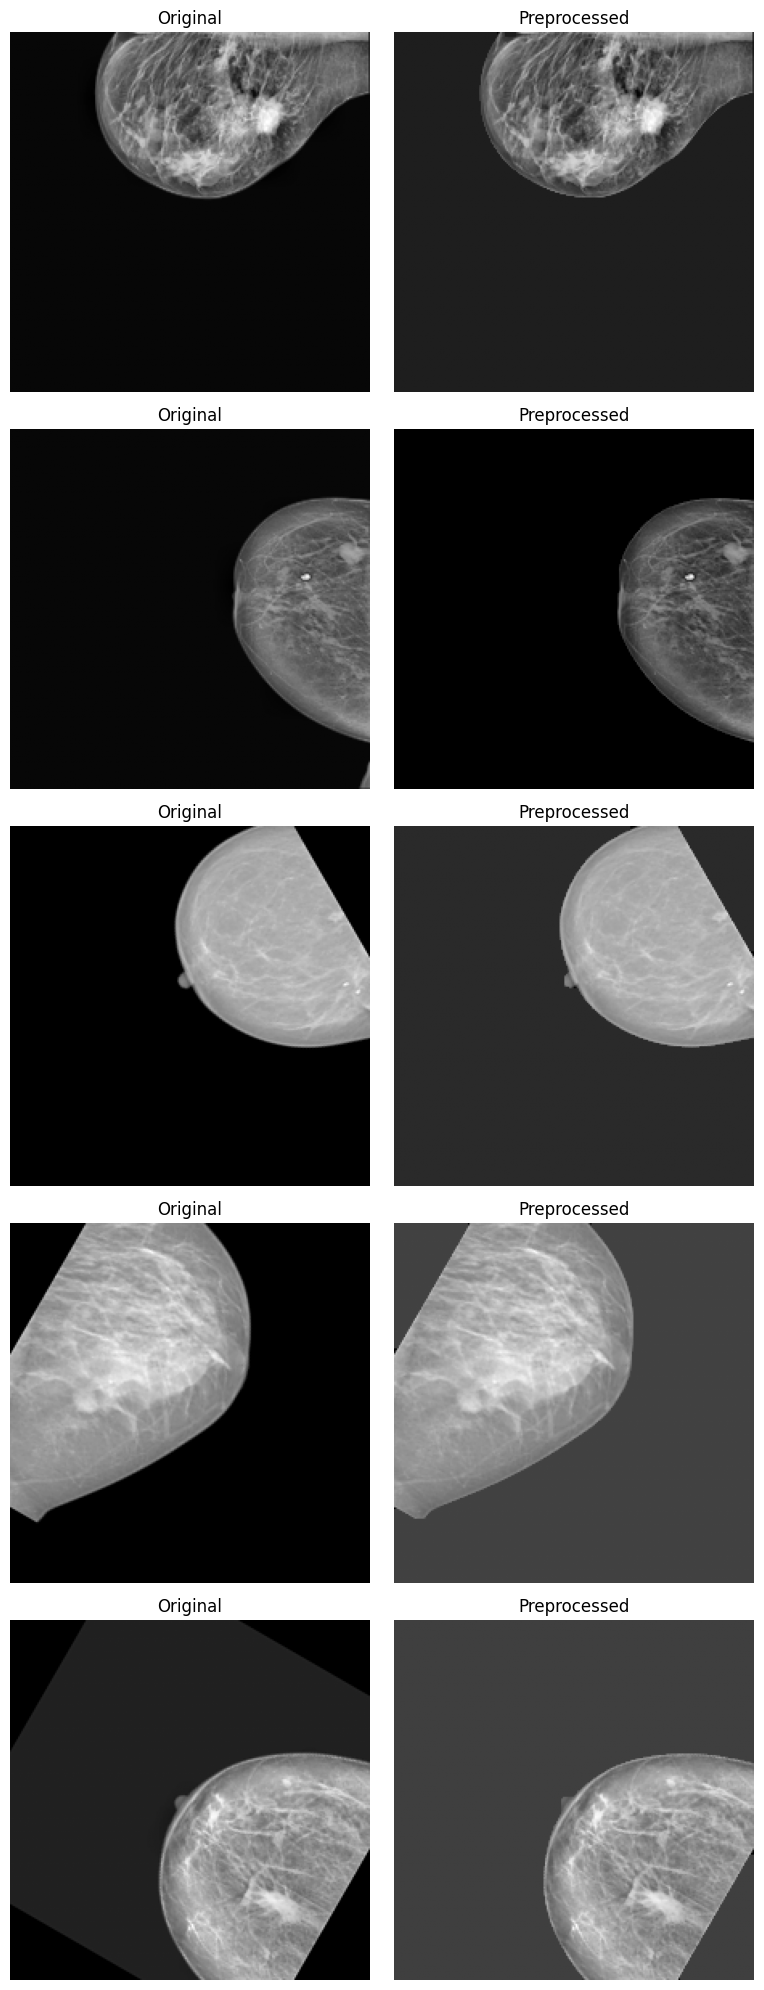

Balancing train_i: Adding 2064 Benign images...
Balancing val_i: Adding 258 Benign images...
Balancing test_i: Adding 258 Benign images...

FINAL DATASET STATISTICS
train_i: Total=8160 | Benign=4080 | Malignant=4080
val_i: Total=1020 | Benign=510 | Malignant=510
test_i: Total=1020 | Benign=510 | Malignant=510


In [1]:
import os
import cv2
import shutil
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
from tqdm.auto import tqdm
from sklearn.model_selection import train_test_split
from torchvision import transforms

# --- 1. PREPROCESSOR ---
class MammoPreprocessor:
    def __init__(self):
        self.resize_op = transforms.Resize((224, 224))

    def z_score_normalize(self, img):
        mean = np.mean(img)
        std = np.std(img) + 1e-8
        return (img - mean) / std

    def breast_segmentation(self, img):
        # Normalize to uint8 for Otsu
        img_uint8 = cv2.normalize(img, None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)

        # Otsu thresholding
        _, thresh = cv2.threshold(img_uint8, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

        # Morphological operations
        kernel = np.ones((5, 5), np.uint8)
        morph = cv2.morphologyEx(thresh, cv2.MORPH_CLOSE, kernel)
        morph = cv2.morphologyEx(morph, cv2.MORPH_OPEN, kernel)

        # Largest connected component
        num_labels, labels, stats, _ = cv2.connectedComponentsWithStats(morph, connectivity=8)

        if num_labels > 1:
            largest_label = 1 + np.argmax(stats[1:, cv2.CC_STAT_AREA])
            mask = (labels == largest_label).astype(np.uint8)
        else:
            mask = np.ones_like(img_uint8)

        segmented = img * mask
        return segmented

    def process(self, pil_img):
        # Resize + grayscale
        img = self.resize_op(pil_img.convert("L"))
        img_np = np.array(img).astype(np.float32)

        # Z-score normalization
        img_norm = self.z_score_normalize(img_np)

        # Segmentation
        img_seg = self.breast_segmentation(img_norm)

        # Back to uint8
        img_out = cv2.normalize(img_seg, None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)

        return Image.fromarray(img_out)


# --- 2. BALANCING AUGMENTATION ---
def get_heavy_balancing_aug():
    return transforms.Compose([
        transforms.RandomAffine(
            degrees=15,
            translate=(0.1, 0.1),
            scale=(0.9, 1.1)
        ),
    ])


# --- 3. PREVIEW FUNCTION ---
def preview_preprocessing(original_paths, processed_dir, num_samples=5):
    samples = np.random.choice(
        range(len(original_paths)),
        min(num_samples, len(original_paths)),
        replace=False
    )

    fig, axes = plt.subplots(len(samples), 2, figsize=(8, 4 * len(samples)))

    if len(samples) == 1:
        axes = np.expand_dims(axes, axis=0)

    for i, idx in enumerate(samples):
        orig_path = original_paths[idx]
        orig_img = Image.open(orig_path).convert("L")

        label = "Benign" if "benign" in orig_path.lower() else "Malignant"
        orig_name = os.path.splitext(os.path.basename(orig_path))[0]

        # Exact match filename
        proc_filename = f"{label}_{orig_name}.png"
        proc_path = os.path.join(processed_dir, proc_filename)

        if not os.path.exists(proc_path):
            continue

        proc_img = Image.open(proc_path)

        axes[i, 0].imshow(orig_img, cmap="gray")
        axes[i, 0].set_title("Original")

        axes[i, 1].imshow(proc_img, cmap="gray")
        axes[i, 1].set_title("Preprocessed")

        for ax in axes[i]:
            ax.axis('off')

    plt.tight_layout()
    plt.show()

# --- 4. MAIN PIPELINE ---
def run_full_mammo_pipeline(base_path, output_base="/kaggle/working/"):

    proc = MammoPreprocessor()
    raw_data = []

    # A. LOAD DATA
    class_map = {
        "benign": "Benign",
        "malignant": "Malignant"
    }

    for folder, label in class_map.items():
        folder_path = os.path.join(base_path, folder)
        if not os.path.exists(folder_path):
            continue

        for f in os.listdir(folder_path):
            if f.lower().endswith(('.png', '.jpg', '.jpeg')):
                raw_data.append({
                    'label': label,
                    'path': os.path.join(folder_path, f)
                })

    df = pd.DataFrame(raw_data)

    # B. SPLIT
    df['label_idx'] = df['label'].map({'Benign': 0, 'Malignant': 1})

    train_df, temp_df = train_test_split(
        df, test_size=0.2, stratify=df['label_idx'], random_state=42
    )

    val_df, test_df = train_test_split(
        temp_df, test_size=0.5, stratify=temp_df['label_idx'], random_state=42
    )

    splits = {
        'train_i': train_df,
        'val_i': val_df,
        'test_i': test_df
    }

    # C. PREPROCESS
    original_paths_for_preview = []

    for folder, d_frame in splits.items():
        out_dir = os.path.join(output_base, folder)
        os.makedirs(out_dir, exist_ok=True)

        print(f"Processing: {folder}")
        for i, row in tqdm(d_frame.iterrows(), total=len(d_frame)):

            if folder == 'train_i':
                original_paths_for_preview.append(row['path'])

            processed = proc.process(Image.open(row['path']))

            orig_name = os.path.splitext(os.path.basename(row['path']))[0]
            fname = f"{row['label']}_{orig_name}.png"
            processed.save(os.path.join(out_dir, fname))

    # D. PREVIEW
    print("\nGenerating preprocessing preview...\n")
    preview_preprocessing(
        original_paths_for_preview,
        os.path.join(output_base, 'train_i'),
        num_samples=5
    )

    # E. BALANCING FUNCTION
    def balance_folder(folder_path, name):
        files = os.listdir(folder_path)
        benign = [f for f in files if 'Benign' in f]
        malignant = [f for f in files if 'Malignant' in f]

        diff = len(benign) - len(malignant)

        aug = get_heavy_balancing_aug()

        if diff > 0:
            print(f"Balancing {name}: Adding {diff} Malignant images...")
            for i in range(diff):
                src = os.path.join(folder_path, np.random.choice(malignant))
                img = Image.open(src)
                aug(img).save(os.path.join(folder_path, f"Malignant_bal_{i}.png"))

        elif diff < 0:
            print(f"Balancing {name}: Adding {-diff} Benign images...")
            for i in range(-diff):
                src = os.path.join(folder_path, np.random.choice(benign))
                img = Image.open(src)
                aug(img).save(os.path.join(folder_path, f"Benign_bal_{i}.png"))

    # Apply balancing
    balance_folder(os.path.join(output_base, 'train_i'), 'train_i')
    balance_folder(os.path.join(output_base, 'val_i'), 'val_i')
    balance_folder(os.path.join(output_base, 'test_i'), 'test_i')

    # F. ZIP
    shutil.make_archive('/kaggle/working/mammo_dataset', 'zip', output_base)

    # G. STATS
    print("\n" + "=" * 40)
    print("FINAL DATASET STATISTICS")
    print("=" * 40)

    for folder in splits.keys():
        path = os.path.join(output_base, folder)
        files = os.listdir(path)

        b_cnt = len([f for f in files if 'Benign' in f])
        m_cnt = len([f for f in files if 'Malignant' in f])

        print(f"{folder}: Total={len(files)} | Benign={b_cnt} | Malignant={m_cnt}")

    print("=" * 40)


# --- EXECUTION ---
dataset_path = "/kaggle/input/datasets/lilyofthevalley6666/breast-mammogphy-dataset-inbreast-database/Breast Mammogphy dataset (INbreast database)"
run_full_mammo_pipeline(dataset_path)